# EDA - Stress Detection from Social Media Text

## Questions This EDA Answers

| Figure | Research Question |
|--------|-----------------------------|
| Fig 1 | How common is each stress level in society? Is the data representative? |
| Fig 2 | Do stressed people write more or less than non-stressed people? |
| Fig 3 | What words do people use when they are stressed vs calm? |
| Fig 4 | Which words are the strongest warning signals of stress? |
| Fig 5 | Can writing style alone (punctuation, uppercase) reveal mental state? |
| Fig 6 | Which features are most reliable for automatic stress detection? |

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         11,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linewidth':    0.5,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
})

COLORS = {'Low': '#2166AC', 'Medium': '#F4A582', 'High': '#D6604D'}
ORDER  = ['Low', 'Medium', 'High']

raw = pd.read_csv('stress_dataset_final_merged.csv')
pre = pd.read_csv('df_preprocessed.csv')
pre['label'] = pre['label_encoded'].map({0:'Low', 1:'Medium', 2:'High'})

print(f'Raw dataset      : {raw.shape[0]:,} rows × {raw.shape[1]} columns')
print(f'Preprocessed     : {pre.shape[0]:,} rows × {pre.shape[1]} columns')
print(f'Samples removed  : {raw.shape[0] - pre.shape[0]} (duplicates / short texts)')
pre.head(5)

Raw dataset      : 21,436 rows × 2 columns
Preprocessed     : 20,965 rows × 8 columns
Samples removed  : 471 (duplicates / short texts)


,cleaned_text,label_encoded,word_count,text_length,avg_word_length,punct_count,uppercase_ratio,label
0,nevermind every other weekend google didnt thi...,1,10,63,5.400000,4,0.035714,Medium
1,name arrest lie obstruction fbi collusion calm...,1,9,56,5.333333,2,0.083333,Medium
2,well damn im go buckingham today,1,6,32,4.500000,0,0.069767,Medium
3,these both beauties those big dark eye smile,0,8,44,4.625000,2,0.033333,Low
4,remind days,1,2,11,5.000000,1,0.000000,Medium


---
## Figure 1 - Dataset Overview & Distribution

**Question:** *How common is each stress level in online social media? Is our dataset balanced enough for fair model training?*

**Why this matters:** If one class dominates, the model will be biased. A balanced dataset ensures the classifier learns equally from all stress levels making it reliable for real-world deployment.

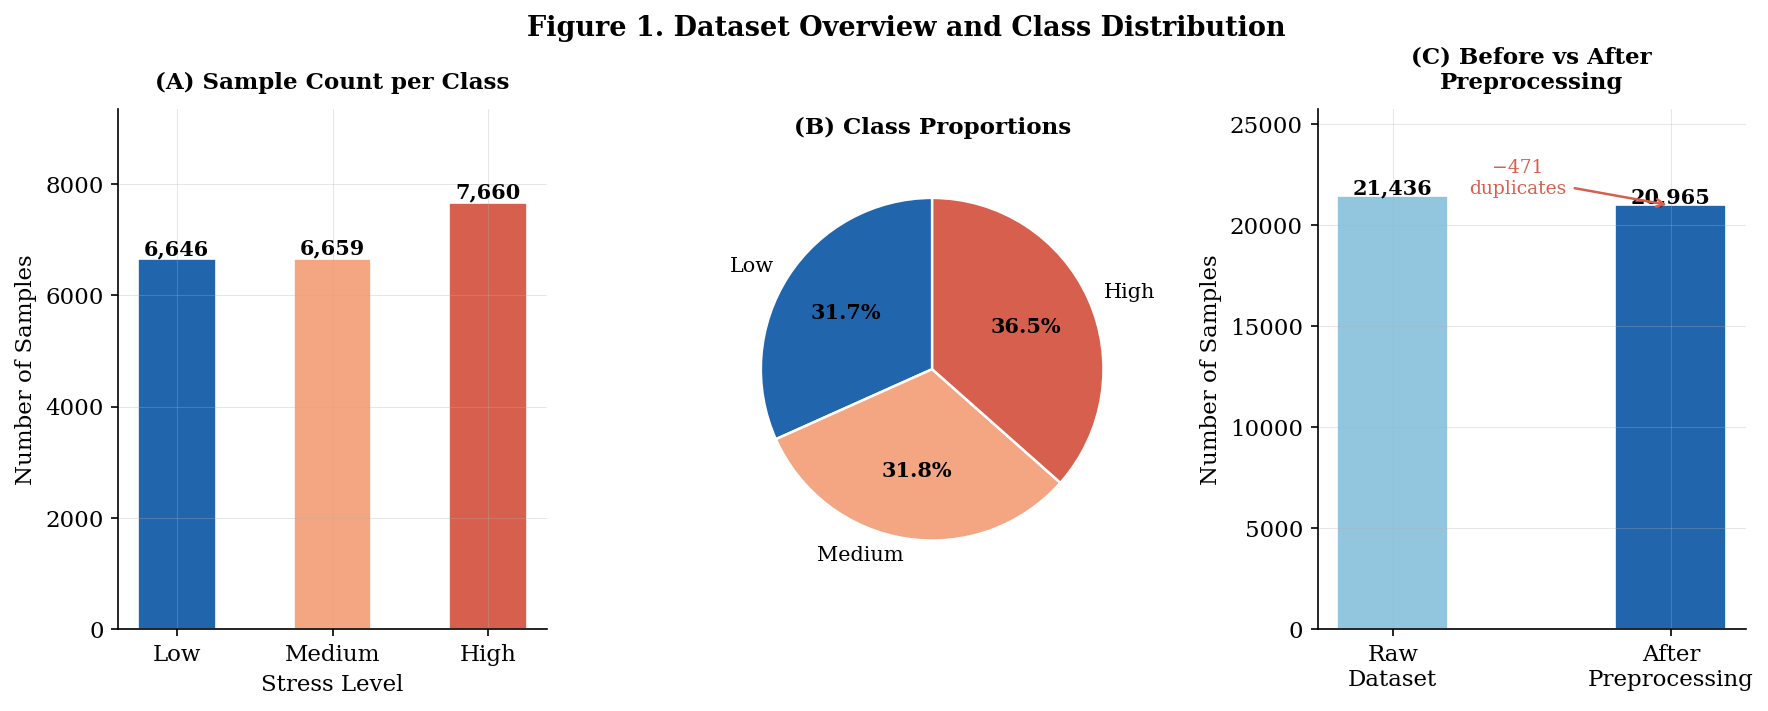

In [19]:
from matplotlib.gridspec import GridSpec

counts = pre['label'].value_counts().reindex(ORDER)
total  = len(pre)

fig = plt.figure(figsize=(14, 4.5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.4)

# Bar chart
ax1 = fig.add_subplot(gs[0])
bars = ax1.bar(ORDER, counts.values,
               color=[COLORS[l] for l in ORDER],
               width=0.5, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 80,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('(A) Sample Count per Class', fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Stress Level')
ax1.set_ylabel('Number of Samples')
ax1.set_ylim(0, max(counts.values) * 1.22)

# Pie chart
ax2 = fig.add_subplot(gs[1])
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=ORDER,
    colors=[COLORS[l] for l in ORDER],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.2),
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('(B) Class Proportions', fontsize=11, fontweight='bold', pad=10)

# Before vs After preprocessing
ax3 = fig.add_subplot(gs[2])
stages = ['Raw\nDataset', 'After\nPreprocessing']
values = [len(raw), len(pre)]
removed = len(raw) - len(pre)
bar2 = ax3.bar(stages, values,
               color=['#92C5DE', '#2166AC'],
               width=0.4, edgecolor='white', linewidth=0.8)
for bar, val in zip(bar2, values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax3.annotate(f'−{removed:,}\nduplicates', fontsize=9, color='#D6604D',
             xy=(1, len(pre)), xytext=(0.45, len(pre)+600), ha='center',
             arrowprops=dict(arrowstyle='->', color='#D6604D', lw=1.2))
ax3.set_title('(C) Before vs After\nPreprocessing', fontsize=11, fontweight='bold', pad=10)
ax3.set_ylabel('Number of Samples')
ax3.set_ylim(0, max(values) * 1.2)

fig.suptitle('Figure 1. Dataset Overview and Class Distribution',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig('fig1_dataset_overview.png')
plt.show()

---
## Figure 2 - Text Length Analysis

**Question:** *Do people write differently depending on their stress level? Does stress cause people to express more or less?*

**Why this matters:** If high-stress users consistently write longer texts, text length becomes a meaningful signal. This finding supports the use of length-based features in the classification model.

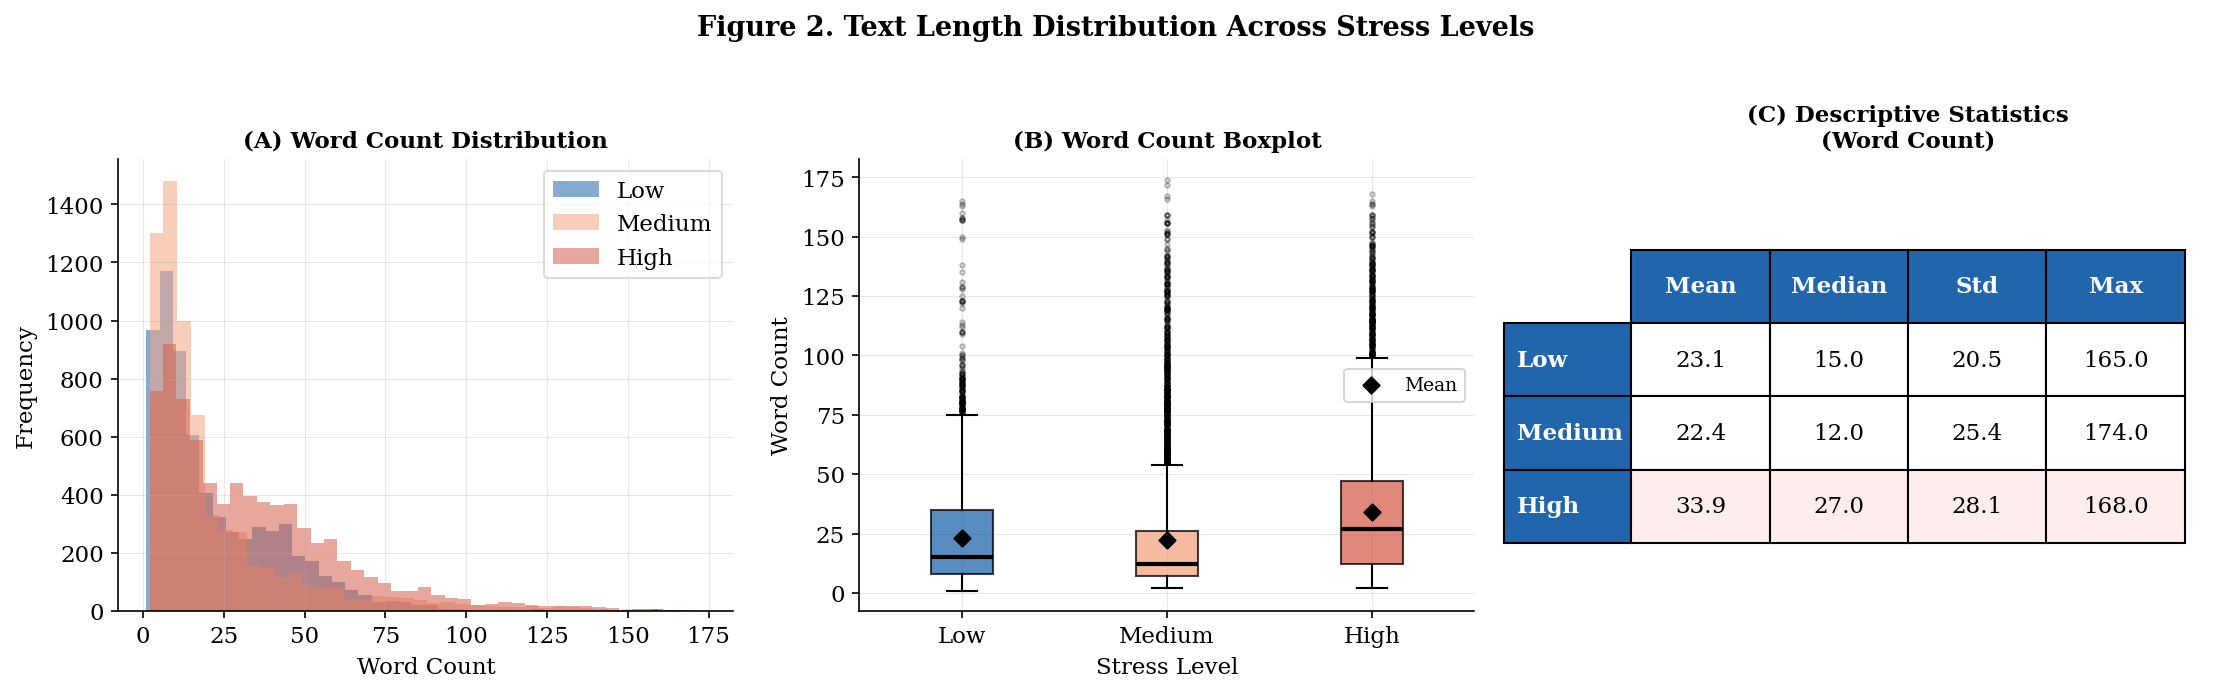

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Figure 2. Text Length Distribution Across Stress Levels',
             fontsize=13, fontweight='bold', y=1.02)

# Histogram
for label in ORDER:
    subset = pre[pre['label'] == label]['word_count']
    axes[0].hist(subset, bins=40, alpha=0.55,
                 color=COLORS[label], label=label, edgecolor='none')
axes[0].set_title('(A) Word Count Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend(framealpha=0.7)

# Boxplot
data_box = [pre[pre['label'] == l]['word_count'].values for l in ORDER]
bp = axes[1].boxplot(data_box, patch_artist=True, labels=ORDER,
                     medianprops=dict(color='black', linewidth=2),
                     flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, label in zip(bp['boxes'], ORDER):
    patch.set_facecolor(COLORS[label])
    patch.set_alpha(0.75)

means = [pre[pre['label'] == l]['word_count'].mean() for l in ORDER]
axes[1].scatter(range(1, 4), means, marker='D', color='black', s=30, zorder=5, label='Mean')
axes[1].legend(fontsize=9)
axes[1].set_title('(B) Word Count Boxplot', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Stress Level')
axes[1].set_ylabel('Word Count')

# Stats table
axes[2].axis('off')
stats = pre.groupby('label')['word_count'].agg(
    Mean='mean', Median='median', Std='std', Max='max'
).reindex(ORDER).round(1)
tbl = axes[2].table(
    cellText=stats.values,
    rowLabels=stats.index,
    colLabels=stats.columns,
    cellLoc='center', loc='center',
    bbox=[0.05, 0.15, 0.9, 0.65]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
for (r, c), cell in tbl.get_celld().items():
    if r == 0 or c == -1:
        cell.set_facecolor('#2166AC')
        cell.set_text_props(color='white', fontweight='bold')
    elif r == 3:  # High row
        cell.set_facecolor('#FFEDED')
axes[2].set_title('(C) Descriptive Statistics\n(Word Count)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_text_length.png')
plt.show()

---
## Figure 3 - Word Clouds by Stress Level

**Question:** *What are people actually saying when they are stressed? Is there a distinct vocabulary associated with high stress vs low stress?*

**Why this matters:** Word clouds reveal the emotional vocabulary of each class. Words like 'anxiety' and 'feel' dominating high-stress posts suggest that people externalize emotional distress through specific language patterns, an important signal for NLP-based detection.

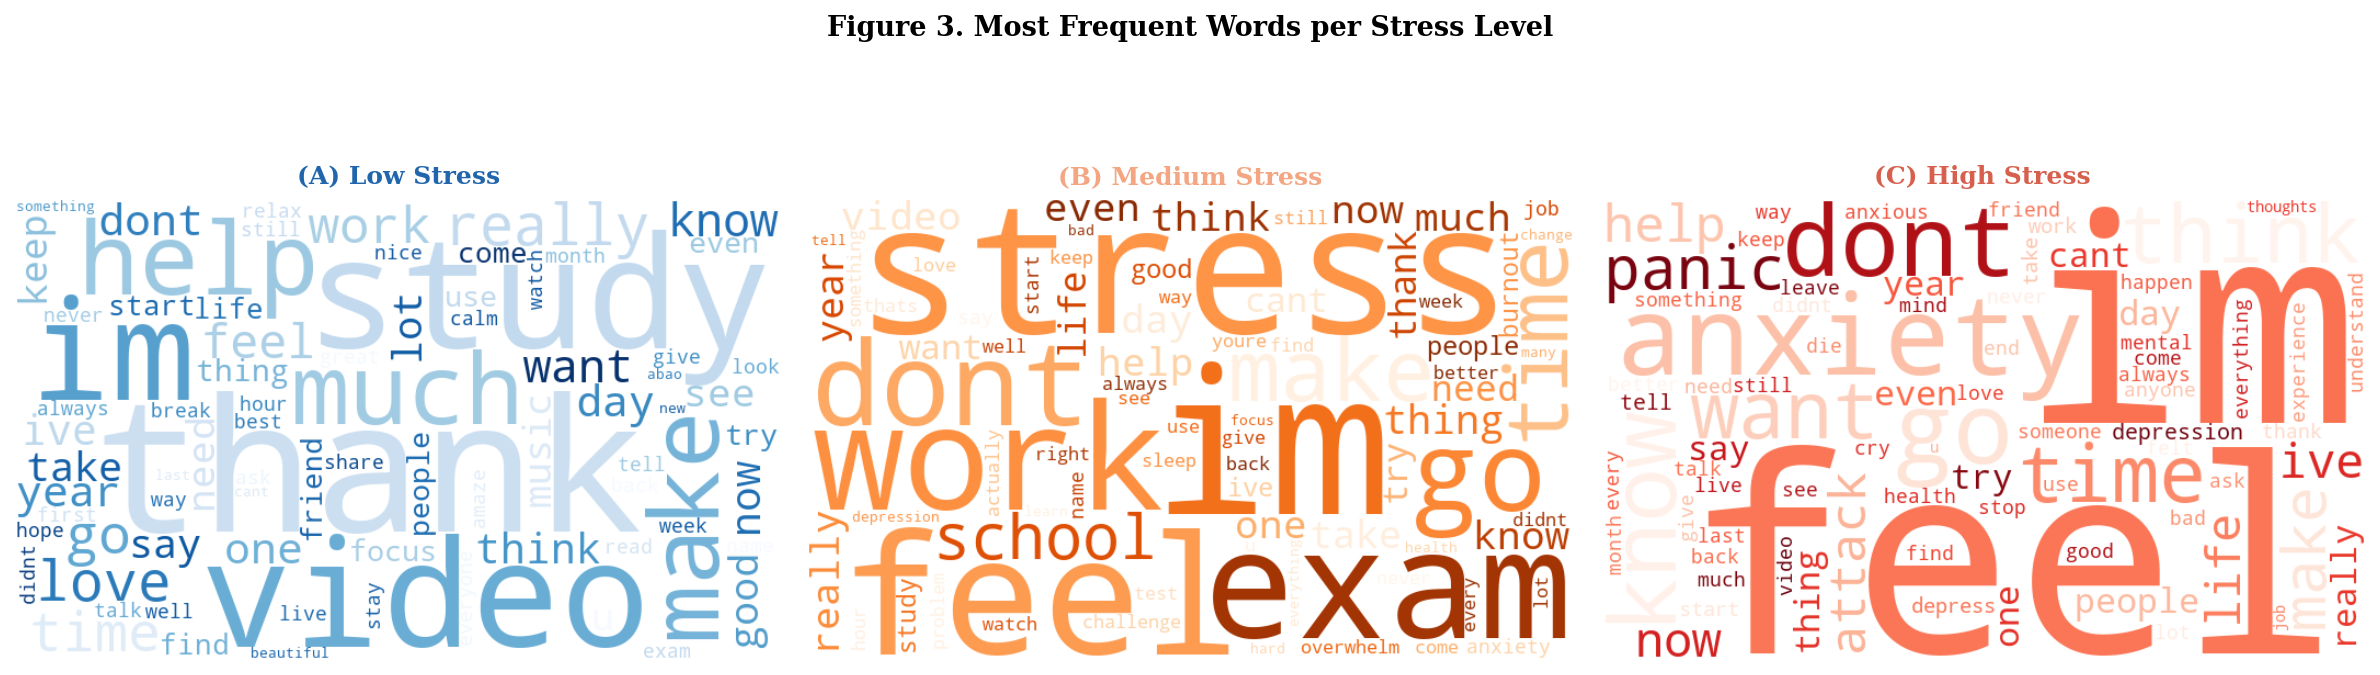

In [21]:
WC_COLORS = {'Low': 'Blues', 'Medium': 'Oranges', 'High': 'Reds'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 3. Most Frequent Words per Stress Level',
             fontsize=13, fontweight='bold', y=1.02)

panel = ['(A)', '(B)', '(C)']
for ax, label, p in zip(axes, ORDER, panel):
    text = ' '.join(pre[pre['label'] == label]['cleaned_text'].dropna().values)
    wc = WordCloud(
        width=700, height=420,
        background_color='white',
        colormap=WC_COLORS[label],
        max_words=80,
        collocations=False,
        prefer_horizontal=0.9
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{p} {label} Stress', fontsize=12,
                 fontweight='bold', color=COLORS[label], pad=8)
    # Add thin border
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS[label])
        spine.set_linewidth(1.5)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig('fig3_wordclouds.png')
plt.show()

---
## Figure 4 - Top Keywords per Stress Class

**Question:** *Which specific words are the strongest warning signals of stress? Can we identify a stress vocabulary?*

**Why this matters:** Unlike word clouds, this figure shows exact frequencies. Words like 'anxiety' appearing exclusively or predominantly in High-stress posts can act as direct features or validation for model attention weights in BERT-based models.

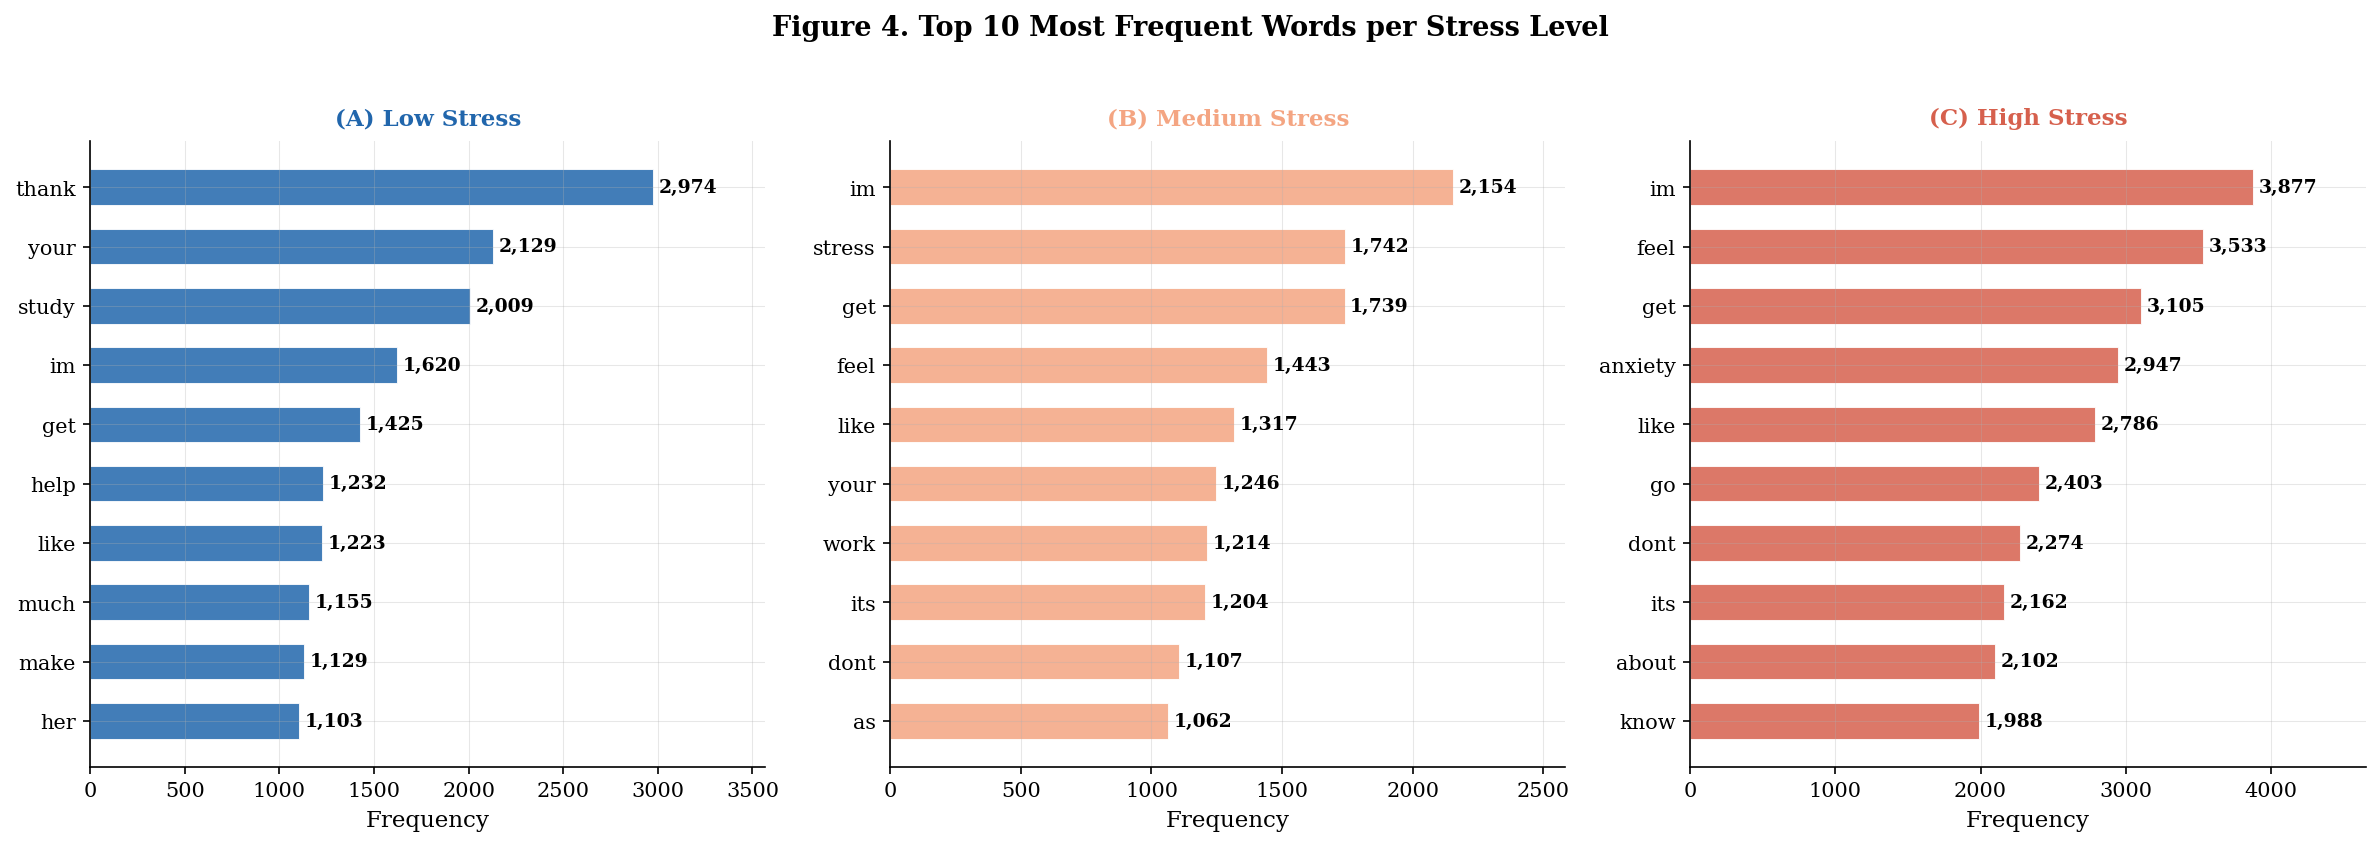

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('Figure 4. Top 10 Most Frequent Words per Stress Level',
             fontsize=13, fontweight='bold', y=1.02)

panel = ['(A)', '(B)', '(C)']
for ax, label, p in zip(axes, ORDER, panel):
    text  = ' '.join(pre[pre['label'] == label]['cleaned_text'].dropna().values)
    top10 = Counter(text.split()).most_common(10)
    words, freqs = zip(*top10)
    words, freqs = list(reversed(words)), list(reversed(freqs))

    bars = ax.barh(words, freqs,
                   color=COLORS[label], alpha=0.85,
                   height=0.6, edgecolor='white', linewidth=0.5)
    for bar, freq in zip(bars, freqs):
        ax.text(bar.get_width() + max(freqs)*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{freq:,}', va='center', fontsize=9, fontweight='bold')

    ax.set_title(f'{p} {label} Stress', fontsize=11,
                 fontweight='bold', color=COLORS[label], pad=8)
    ax.set_xlabel('Frequency')
    ax.set_xlim(0, max(freqs) * 1.2)
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('fig4_top_keywords.png')
plt.show()

---
## Figure 5 - Engineered Feature Analysis

**Research Question:** *Can writing style alone without reading the content reveal a person's mental state?*

**Why this matters:** If punctuation count, uppercase ratio, and word length differ significantly across stress levels, these features provide the model with signals beyond just word choice. This is especially important for short texts where vocabulary alone may not be sufficient.

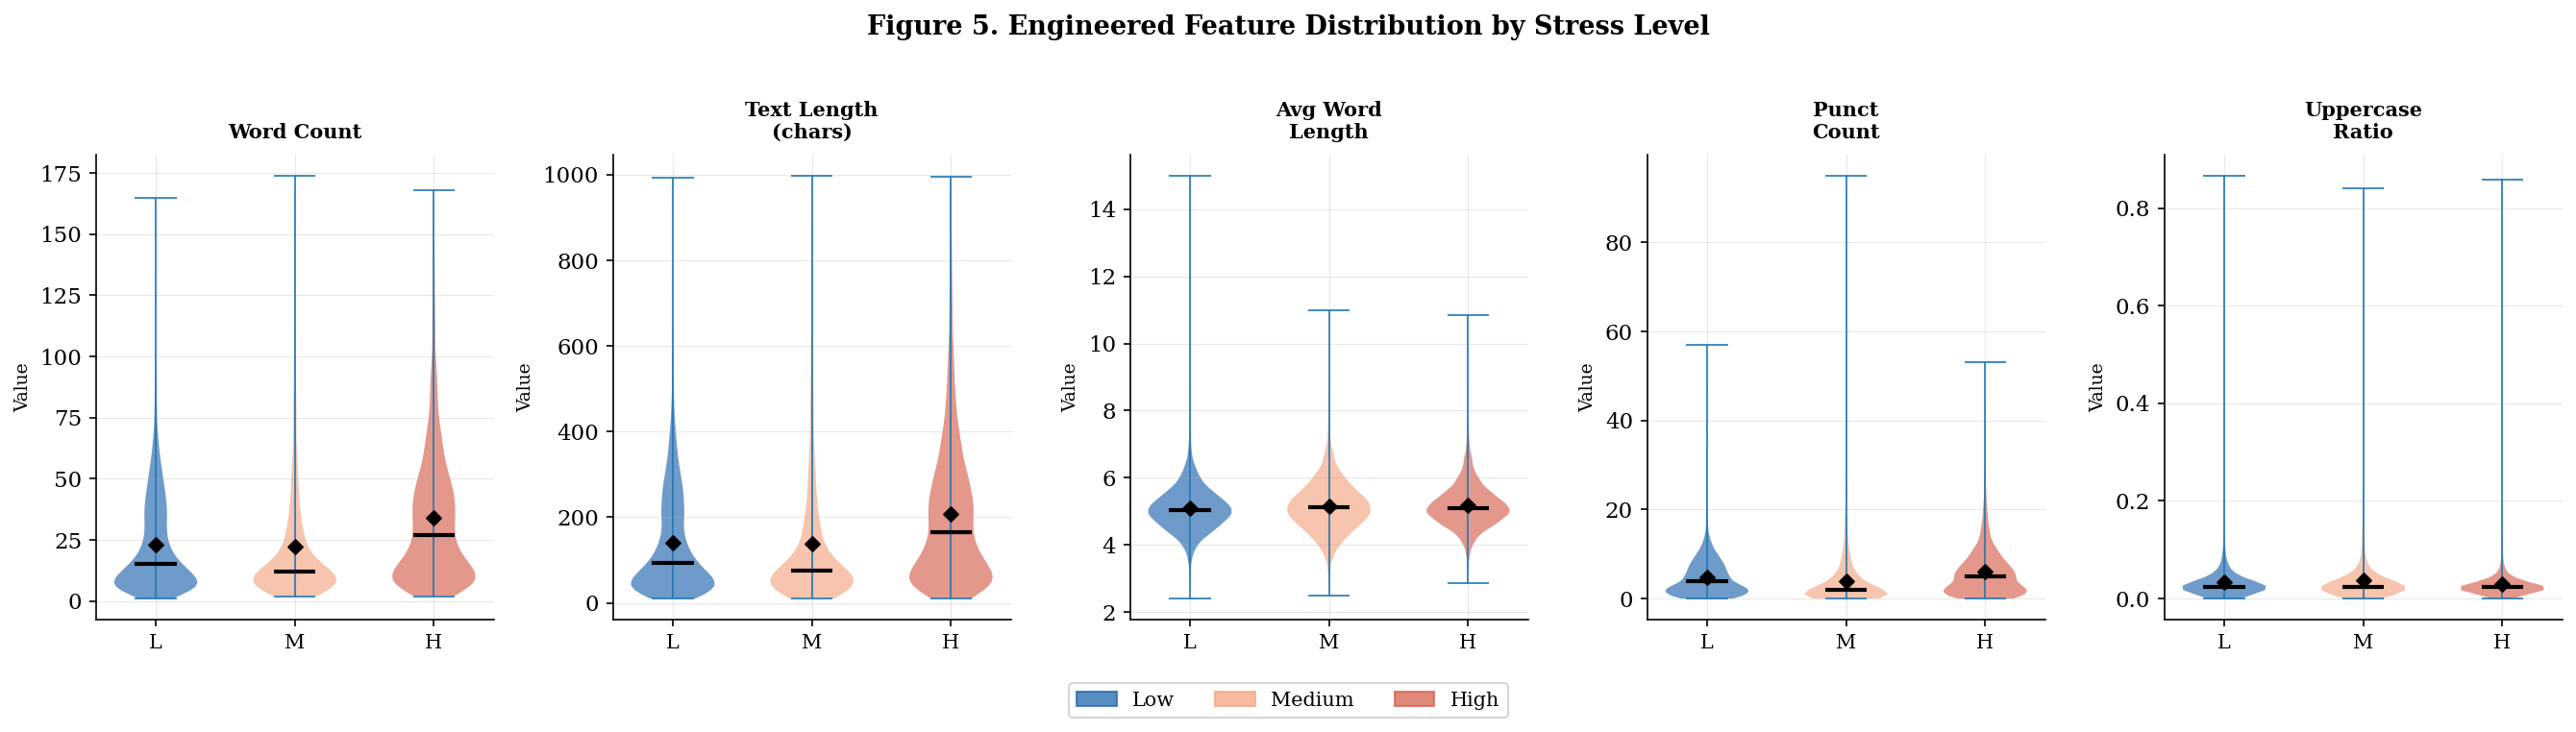

In [23]:
features    = ['word_count', 'text_length', 'avg_word_length', 'punct_count', 'uppercase_ratio']
feat_labels = ['Word Count', 'Text Length\n(chars)', 'Avg Word\nLength', 'Punct\nCount', 'Uppercase\nRatio']

fig, axes = plt.subplots(1, 5, figsize=(18, 4.5))
fig.suptitle('Figure 5. Engineered Feature Distribution by Stress Level',
             fontsize=13, fontweight='bold', y=1.02)

for ax, feat, feat_label in zip(axes, features, feat_labels):
    data = [pre[pre['label'] == l][feat].values for l in ORDER]

    # Violin
    parts = ax.violinplot(data, positions=[1, 2, 3],
                          showmedians=True, showmeans=False,
                          widths=0.6)
    for pc, label in zip(parts['bodies'], ORDER):
        pc.set_facecolor(COLORS[label])
        pc.set_alpha(0.65)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    parts['cbars'].set_linewidth(0.8)
    parts['cmaxes'].set_linewidth(0.8)
    parts['cmins'].set_linewidth(0.8)

    # Add mean dots
    means = [np.mean(d) for d in data]
    ax.scatter([1,2,3], means, marker='D', color='black', s=25, zorder=5)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['L', 'M', 'H'], fontsize=10)
    ax.set_title(feat_label, fontsize=10, fontweight='bold', pad=8)
    ax.set_ylabel('Value', fontsize=9)

legend_patches = [mpatches.Patch(color=COLORS[l], label=l, alpha=0.75) for l in ORDER]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           framealpha=0.8, fontsize=10, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig('fig5_features.png')
plt.show()

---
## Figure 6 - Feature Correlation Matrix

**Research Question:** *Which features are most reliably associated with stress level? Are any features redundant?*

**Why this matters:** High correlation between two features means one may be dropped without losing information - simplifying the model. Correlation with `label_encoded` directly shows which features are the strongest predictors of stress, guiding feature selection decisions.

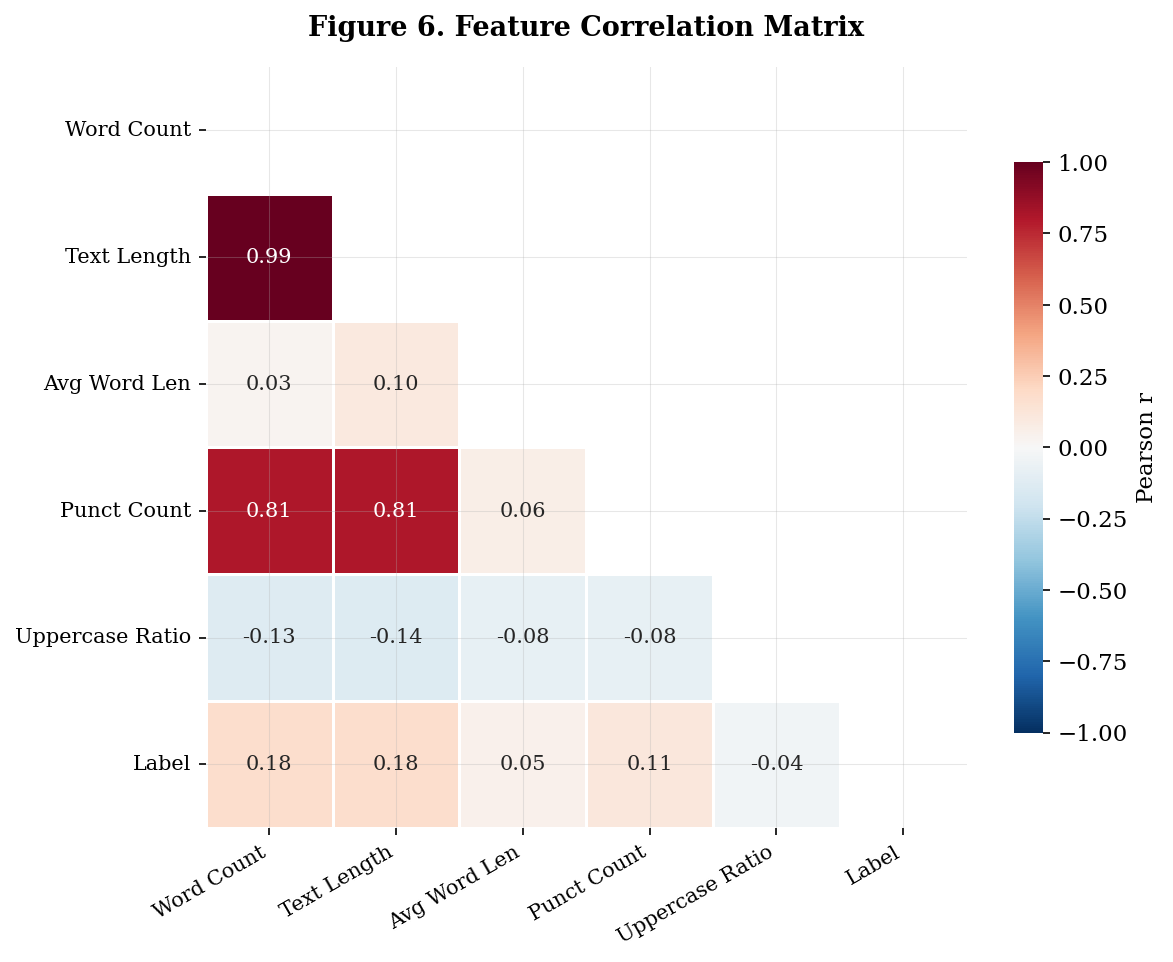

Feature correlation with stress label:
  Word Count           r = +0.179
  Text Length          r = +0.178
  Avg Word Len         r = +0.112
  Punct Count          r = +0.047
  Uppercase Ratio      r = -0.036


In [24]:
features    = ['word_count', 'text_length', 'avg_word_length', 'punct_count', 'uppercase_ratio']
feat_labels = ['Word Count', 'Text Length', 'Avg Word Len', 'Punct Count', 'Uppercase Ratio']
corr_cols   = features + ['label_encoded']
corr        = pre[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 10},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
    xticklabels=feat_labels + ['Label'],
    yticklabels=feat_labels + ['Label'],
    ax=ax
)

ax.set_title('Figure 6. Feature Correlation Matrix',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('fig6_correlation.png')
plt.show()

# Print strongest predictors
label_corr = corr['label_encoded'].drop('label_encoded').sort_values(key=abs, ascending=False)
print('Feature correlation with stress label:')
for feat, val in zip(feat_labels, label_corr.values):
    print(f'  {feat:<20} r = {val:+.3f}')